# EDA Notebook on Selecting Features

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc
from tqdm import tqdm
from typing import Tuple, List
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("../data/interim/ieee-fraud-detection")
TARGET_COLUMN = "isFraud"
ID_COLUMN = "TransactionID"
TIME_COLUMN = "TransactionDT"

In [3]:
df_original_train = pd.read_parquet(DATA_DIR / "train.parquet")

In [4]:
def temporal_balanced_train_test_split(
    df: pd.DataFrame,
    time_col: str = TIME_COLUMN,
    target_col: str = TARGET_COLUMN,
    train_ratio: float = 0.8,
    train_search_width: float = 0.05,
    min_test_pos: int = 200,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split the data into training and test sets based on temporal order and target balance."""
    # Sort the data by time and reset the index
    df = df.sort_values(time_col)
    # n = len(df)
    # y = df[target_col].to_numpy()

    # # Define the range of possible split points to search for the best balance between training and test sets.
    # train_range = range(
    #     max(1, int(n * (train_ratio - train_search_width))),
    #     min(n - 2, int(n * (train_ratio + train_search_width))) + 1
    # )

    # # Iterate over the possible split points and calculate the target rate in the training and test sets.
    # # best = None
    # train_end = 0
    # best_score = float("inf")

    # for i in tqdm(train_range):
    #     y_train = y[: i]
    #     y_test = y[i: ]

    #     if len(y_test) == 0:
    #         continue

    #     n_test_pos = y_test.sum()
    #     if n_test_pos < min_test_pos:
    #         continue

    #     train_target_rate = y_train.mean()
    #     test_target_rate = y_test.mean()
    #     score = abs(train_target_rate - test_target_rate)

    #     if score < best_score:
    #         best_score = score
    #         train_end = i
    
    # print(f"Selected split point at index {train_end} with train target rate {y[:train_end].mean():.4f} and test target rate {y[train_end:].mean():.4f}")
    train_end = 498700
    df_main = df.iloc[: train_end]
    df_local_test = df.iloc[train_end :]
    return df_main, df_local_test

df_main, df_local_test = temporal_balanced_train_test_split(df_original_train)

# Step 1: Determine V Features

1. Find V features with the same number of missing values
2. Compute these features' correlation
3. Use Hierarchical Clustering to find the subgroups of features that are highly correlated
4. Among the subgroup, select one feature that correlates more to target variable and has higher variance for spreading wider

In [5]:
def remove_high_corr(
    df: pd.DataFrame,
    cols: List[str],
    target_col: str = TARGET_COLUMN,
    threshold: float = 0.65,
) -> List[str]:
    if len(cols) <= 1:
        return cols.copy()

    # Absolute correlation matrix
    corr_matrix = df[cols].corr().abs()
    corr_matrix = corr_matrix.fillna(0.0)
    np.fill_diagonal(corr_matrix.values, 1.0)

    # Convert to distance matrix: small distance = high correlation
    dist_matrix = 1 - corr_matrix

    # Condensed distance format required by scipy linkage
    condensed_dist = squareform(dist_matrix.values, checks=False)

    # Hierarchical clustering
    Z = linkage(condensed_dist, method="average")

    # Cut the dendrogram
    cluster_labels = fcluster(Z, t=1 - threshold, criterion="distance")

    # Collect groups
    cluster_map = {}
    for col, label in zip(cols, cluster_labels):
        cluster_map.setdefault(label, []).append(col)

    groups = list(cluster_map.values())

    # Sort columns inside each group numerically if possible
    def sort_key(x: str):
        digits = "".join(ch for ch in x if ch.isdigit())
        return (x.rstrip(digits), int(digits)) if digits else (x, 0)

    groups = [sorted(group, key=sort_key) for group in groups]
    groups = sorted(groups, key=lambda g: sort_key(g[0]))

    # Keep one representative per group: highest nunique
    def score(c):
        # Combine correlation with target and variance to select representative column
        # Higher correlation with target and higher variance is preferred
        target_corr = abs(df[c].corr(df[target_col]))
        var = df[c].var()
        return target_corr + 0.01 * var    

    keep_cols = [max(group, key=lambda c: score(c)) for group in groups]
    return keep_cols

In [6]:
nan_counts = df_main.isna().sum()

V_groups_with_same_nan_counts = [
    [col for col in cols if col.startswith("V")]
    for null_count, cols in nan_counts.groupby(nan_counts).groups.items()
    if null_count > 0 and len(cols) > 1 and any(col.startswith("V") for col in cols)
]

less_correlated_V_columns = []
for group in tqdm(V_groups_with_same_nan_counts):
    less_correlated_V_columns += remove_high_corr(df_main, group)
    
less_correlated_V_columns    

100%|██████████| 14/14 [00:13<00:00,  1.03it/s]


['V307',
 'V284',
 'V285',
 'V286',
 'V299',
 'V298',
 'V304',
 'V305',
 'V308',
 'V309',
 'V310',
 'V320',
 'V101',
 'V96',
 'V98',
 'V99',
 'V106',
 'V105',
 'V107',
 'V108',
 'V109',
 'V111',
 'V117',
 'V120',
 'V121',
 'V123',
 'V128',
 'V127',
 'V131',
 'V130',
 'V134',
 'V281',
 'V283',
 'V289',
 'V296',
 'V301',
 'V314',
 'V12',
 'V14',
 'V18',
 'V20',
 'V23',
 'V26',
 'V27',
 'V29',
 'V53',
 'V56',
 'V74',
 'V62',
 'V65',
 'V67',
 'V68',
 'V69',
 'V75',
 'V78',
 'V79',
 'V83',
 'V87',
 'V88',
 'V89',
 'V90',
 'V35',
 'V38',
 'V52',
 'V41',
 'V45',
 'V47',
 'V48',
 'V1',
 'V3',
 'V5',
 'V7',
 'V9',
 'V10',
 'V220',
 'V222',
 'V234',
 'V239',
 'V251',
 'V271',
 'V169',
 'V201',
 'V175',
 'V180',
 'V185',
 'V197',
 'V210',
 'V209',
 'V203',
 'V173',
 'V181',
 'V215',
 'V205',
 'V211',
 'V257',
 'V264',
 'V223',
 'V265',
 'V237',
 'V240',
 'V260',
 'V268',
 'V275',
 'V324',
 'V323',
 'V325',
 'V330',
 'V332',
 'V335',
 'V138',
 'V140',
 'V142',
 'V160',
 'V147',
 'V158',
 'V162']

# Step 2: Determine UID Features

1. Select some features as major component for UID (card1, addr1)
2. Perform adversarial validation, label 0 for features from training set, and label 1 for features from test set
3. Use a model to predict this label

In [13]:
basic_columns = [
    column for column in df_main.columns 
    if not column.startswith("V") 
    and not column.startswith("id") 
    and not column.startswith("Device") 
    and column != "isFraud"
    and column != "TransactionDT"
    and column != "TransactionID"
    and column != "belong_to_test_set"
]

In [14]:
basic_columns

['TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9']

In [8]:
df_main["belong_to_test_set"] = 0
df_local_test["belong_to_test_set"] = 1

df_adv = pd.concat([df_main, df_local_test])

In [9]:
del df_main, df_local_test, df_original_train
gc.collect()

0

In [ ]:
normalized_D_columns = []
for i in tqdm(range(1, 16)):
    if i == 9:   
        continue 
    # 1000 is added to ensure that the normalized D values are positive, which can be helpful for certain types of analysis and modeling. 
    # The choice of 1000 is somewhat arbitrary but provides a clear separation from any negative values that might arise from the normalization process.
    # Since the smallest DT is 86400, it corresponds to the number of seconds in a day, and dividing by this value effectively normalizes the D columns to a daily scale. 
    # This can help in capturing temporal patterns in the data while keeping the values manageable and interpretable. 
    df_adv[f"D{i}_normalized"] = np.floor(df_adv[f"D{i}"] - df_adv["TransactionDT"] / np.float32(24 * 60 * 60)) + 1000
    normalized_D_columns.append(f"D{i}_normalized")    

100%|██████████| 15/15 [00:00<00:00, 118.69it/s]


In [11]:
df_adv["card1_addr1_D1_uid"] = df_adv["card1"].astype(str) + "_" + df_adv["addr1"].astype(str) + "_" + df_adv["D1_normalized"].astype(str)

In [26]:
good_V_features_in_uid = (df_adv[less_correlated_V_columns + ["card1_addr1_D1_uid"]]
                                  .groupby(["card1_addr1_D1_uid"])
                                  .std()
                                  .mean()
                                  .sort_values()
                                  .reset_index(name="mean_std_of_V_feature_over_uid_groups")
                                  .rename(columns={"index": "V_feature"}))
good_V_features_in_uid["NA_counts_percentage"] = df_adv[good_V_features_in_uid["V_feature"]].isna().sum().values / df_adv.shape[0] * 100
good_V_features_in_uid.query("NA_counts_percentage < 50").sort_values(["mean_std_of_V_feature_over_uid_groups"]).head(20)
# nunique_df
# nunique_df.columns[
#     (nunique_df.max() <= 1)
# ]

,V_feature,mean_std_of_V_feature_over_uid_groups,NA_counts_percentage
0,V305,0.000000,0.002032
1,V1,0.000061,47.293494
2,V68,0.000138,13.055170
3,V89,0.000223,15.098723
4,V27,0.000258,12.881939
5,V65,0.000273,13.055170
6,V14,0.000445,12.881939
7,V41,0.000575,28.612626
8,V88,0.000646,15.098723
9,V107,0.000925,0.053172


In [34]:
df_adv["V14"].describe()

count    514467.00000
mean          0.99950
std           0.02234
min           0.00000
25%           1.00000
50%           1.00000
75%           1.00000
max           1.00000
Name: V14, dtype: float64

In [27]:
good_numerical_features_in_uid = (df_adv[[col for col in df_adv.columns if col.startswith("D") and not col.startswith("D1") and df_adv[col].dtype != "category"] + ["TransactionAmt", "dist1", "card1_addr1_D1_uid"]]
                                  .groupby(["card1_addr1_D1_uid"])
                                  .std()
                                  .mean()
                                  .sort_values()
                                  .reset_index(name="mean_std_of_numerical_feature_over_uid_groups")
                                  .rename(columns={"index": "numerical_feature"}))
good_numerical_features_in_uid["NA_counts_percentage"] = df_adv[good_numerical_features_in_uid["numerical_feature"]].isna().sum().values / df_adv.shape[0] * 100
good_numerical_features_in_uid.query("NA_counts_percentage < 50").sort_values(["mean_std_of_numerical_feature_over_uid_groups"]).head(20)

,numerical_feature,mean_std_of_numerical_feature_over_uid_groups,NA_counts_percentage
1,D2_normalized,0.445864,47.549192
2,D2,26.533262,47.549192
3,D3,29.354229,44.514851
6,D4_normalized,39.686842,28.604667
7,D3_normalized,41.318860,44.514851
11,D4,51.234993,28.604667
13,TransactionAmt,62.437405,0.000000


In [ ]:
# Find all root transaction for the anchor UID
time_column = "TransactionDT"

# First find UID that only has 1 transaction
card1_D1_uid_with_single_transactions = (df_adv
                                       .reset_index()
                                       .groupby(["card1_D1_uid"], dropna=False)
                                       .TransactionID
                                       .size()
                                       .reset_index(name="unique_id_count")
                                       .query("unique_id_count == 1")
                                       .card1_D1_uid
                                       .tolist())

df_adv["uid"] = np.where(
    df_adv["card1_D1_uid"].isin(card1_D1_uid_with_single_transactions), 
    df_adv.index, 
    np.nan
)

# Then find the transaction that appears first in each uid group
root_transactions = (df_adv
                     .sort_values(time_column)
                     .groupby(["card1_D1_uid"])
                     .cumcount()
                     .reset_index(name="appearance_order_in_uid_group")
                     .query("appearance_order_in_uid_group == 0")
                     .TransactionID
                     .tolist())

root_transactions_not_in_single_transaction_uids = (
    set(root_transactions) 
    - set(df_adv[df_adv["card1_D1_uid"].isin(card1_D1_uid_with_single_transactions)].index)
)
df_adv["uid"] = np.where(
    df_adv.index.isin(root_transactions_not_in_single_transaction_uids), 
    df_adv.index, 
    df_adv["uid"]
)

# The very first transaction (Found in D3) happened at least 1 day before the current transaction
# If a previous event exists, but a matching earlier transaction cannot be found, this must be the start of a new chain
df_adv["uid"] = np.where(
    (df_adv['uid'].isna()) & (df_adv["D3_normalized"] < 1001), 
    df_adv.index, 
    df_adv["uid"]
)

In [26]:
df_adv["uid"].isna().sum()

np.int64(233490)

In [119]:
df_adv[(df_adv["card1"] == 1000) & (df_adv["D1_normalized"] == 933)]["D3_normalized"]

TransactionID
3230924   NaN
Name: D3_normalized, dtype: float64

In [56]:
df_adv.isna().sum().reset_index(name="null_count").query("null_count == 0")

,index,null_count
0,isFraud,0
1,TransactionDT,0
2,TransactionAmt,0
3,ProductCD,0
4,card1,0
16,C1,0
17,C2,0
18,C3,0
19,C4,0
20,C5,0


In [11]:
def cross_validated_adversarial_importance(
    df_adv: pd.DataFrame,
    feature_cols: list[str],
    target_col: str = "belong_to_test_set",
    n_splits: int = 3,
    random_state: int = 42,
) -> tuple[pd.DataFrame, list[float]]:
    X = df_adv[feature_cols].copy()
    y = df_adv[target_col].copy()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_gain = []
    all_split = []
    fold_ids = []
    fold_aucs = []

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": 6,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "verbosity": -1,
    }

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        print(f"Fold {fold}")

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        train_data = lgb.Dataset(X_train, label=y_train, free_raw_data=True)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, free_raw_data=True)

        # print(
        #     X_train.shape, X_val.shape,
        #     X_train.memory_usage(deep=True).sum() / 1024**3,
        #     X_val.memory_usage(deep=True).sum() / 1024**3
        # )    
        # del X_train, y_train, X_val, y_val, train_data, val_data
        # gc.collect()            

        bst = lgb.train(
            params,
            train_data,
            num_boost_round=30,
            valid_sets=[val_data],
        )

        y_val_pred = bst.predict(X_val)
        fold_aucs.append(roc_auc_score(y_val, y_val_pred))

        all_gain.append(bst.feature_importance(importance_type="gain"))
        all_split.append(bst.feature_importance(importance_type="split"))
        fold_ids.append(np.full(len(feature_cols), fold))

        del X_train, y_train, X_val, y_val, train_data, val_data, bst, y_val_pred
        gc.collect()

    importance_df = pd.DataFrame({
        "feature": np.tile(feature_cols, len(all_gain)),
        "importance_gain": np.concatenate(all_gain),
        "importance_split": np.concatenate(all_split),
        "fold": np.concatenate(fold_ids),
    })

    aggregated_importance = (
        importance_df
        .groupby("feature", as_index=False)
        .agg(
            mean_gain=("importance_gain", "mean"),
            std_gain=("importance_gain", "std"),
            mean_split=("importance_split", "mean"),
            std_split=("importance_split", "std"),
        )
        .sort_values("mean_gain", ascending=False)
        .reset_index(drop=True)
    )

    return aggregated_importance, fold_aucs

In [69]:
columns_needed = [column for column in basic_columns if column not in [f"D{i}" for i in range(1, 16) if i != 9]] + normalized_D_columns + less_correlated_V_columns
# columns_needed = basic_columns + normalized_D_columns + less_correlated_V_columns

In [70]:
importance_table, aucs = cross_validated_adversarial_importance(
    df_adv=df_adv,
    feature_cols=columns_needed,
    target_col="belong_to_test_set",
    n_splits=5,
    random_state=42,
)

# print("Fold AUCs:", aucs)
# print("Mean AUC:", np.mean(aucs))

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


Text(0, 0.5, 'Feature')

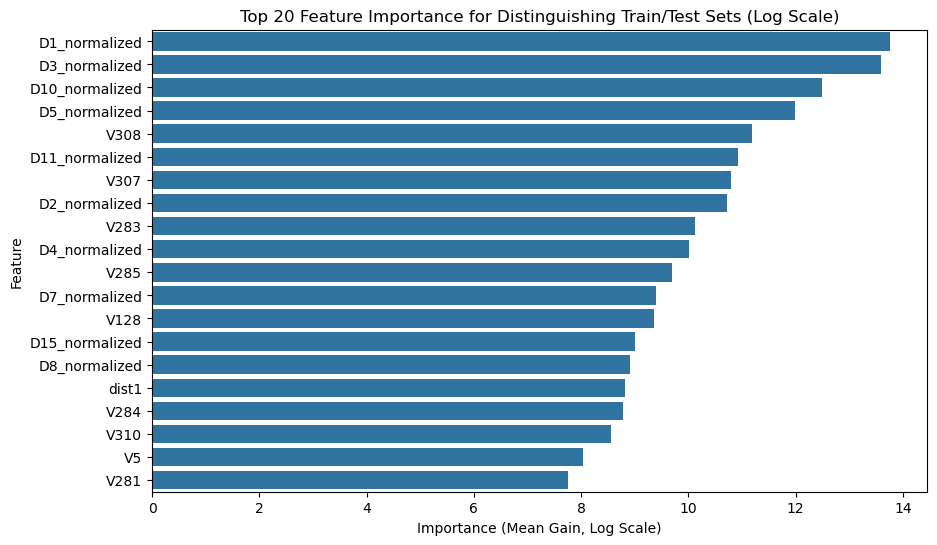

In [71]:
top_amount = 20
plt.figure(figsize=(10, 6))
sns.barplot(x=np.log(importance_table[: top_amount]["mean_gain"]), y=importance_table[: top_amount]["feature"])
plt.title(f"Top {top_amount} Feature Importance for Distinguishing Train/Test Sets (Log Scale)")
plt.xlabel("Importance (Mean Gain, Log Scale)")
plt.ylabel("Feature")

Text(0, 0.5, 'Feature')

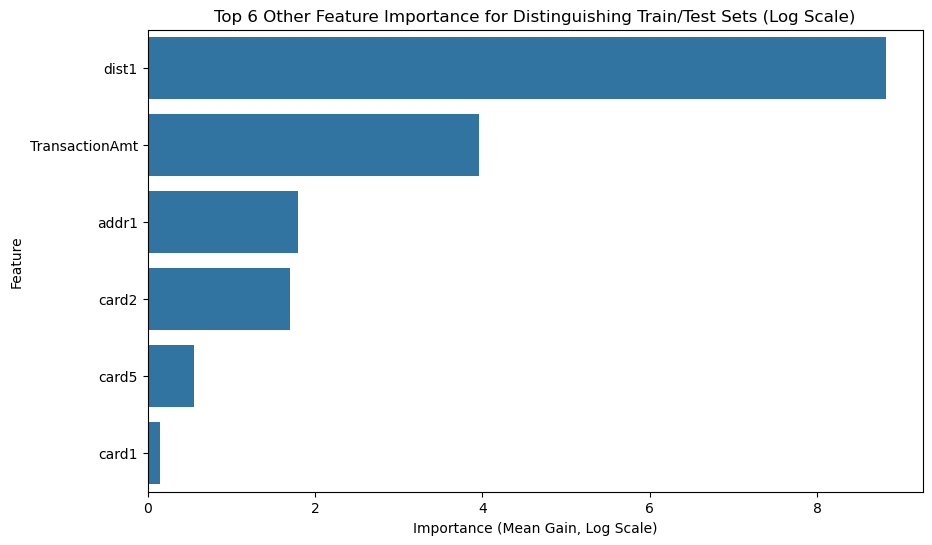

In [72]:
# Plot feature importance descending order
others = importance_table[~importance_table["feature"].str.startswith("D") & ~importance_table["feature"].str.startswith("V") & ~importance_table["feature"].str.startswith("C")].sort_values("mean_gain", ascending=False).reset_index(drop=True)
top_amount = 6
plt.figure(figsize=(10, 6))
sns.barplot(x=np.log(others[: top_amount]["mean_gain"]), y=others[: top_amount]["feature"])
plt.title(f"Top {top_amount} Other Feature Importance for Distinguishing Train/Test Sets (Log Scale)")
plt.xlabel("Importance (Mean Gain, Log Scale)")
plt.ylabel("Feature")

Text(0, 0.5, 'Feature')

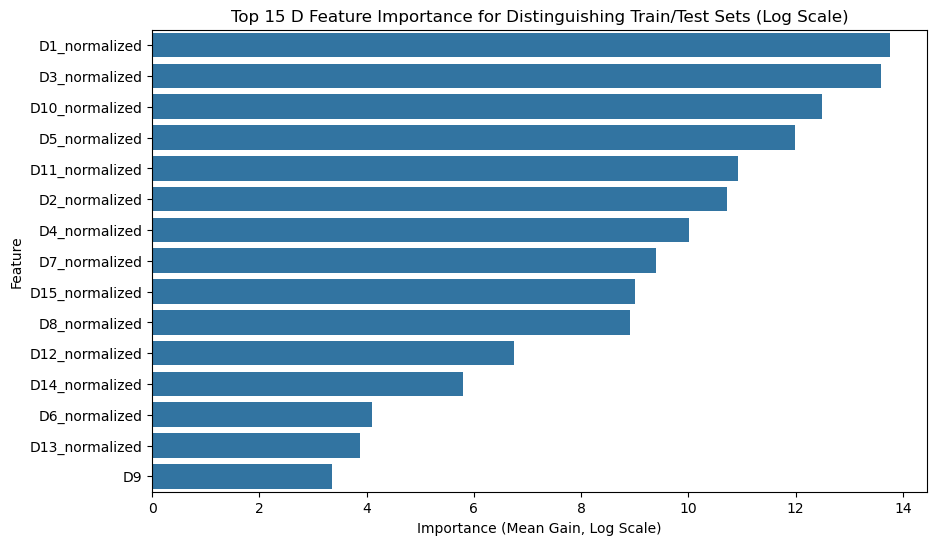

In [73]:
# Plot feature importance descending order
just_D = importance_table[importance_table["feature"].str.startswith("D")].sort_values("mean_gain", ascending=False).reset_index(drop=True)
top_amount = 15
plt.figure(figsize=(10, 6))
sns.barplot(x=np.log(just_D[: top_amount]["mean_gain"]), y=just_D[: top_amount]["feature"])
plt.title(f"Top {top_amount} D Feature Importance for Distinguishing Train/Test Sets (Log Scale)")
plt.xlabel("Importance (Mean Gain, Log Scale)")
plt.ylabel("Feature")

Text(0, 0.5, 'Feature')

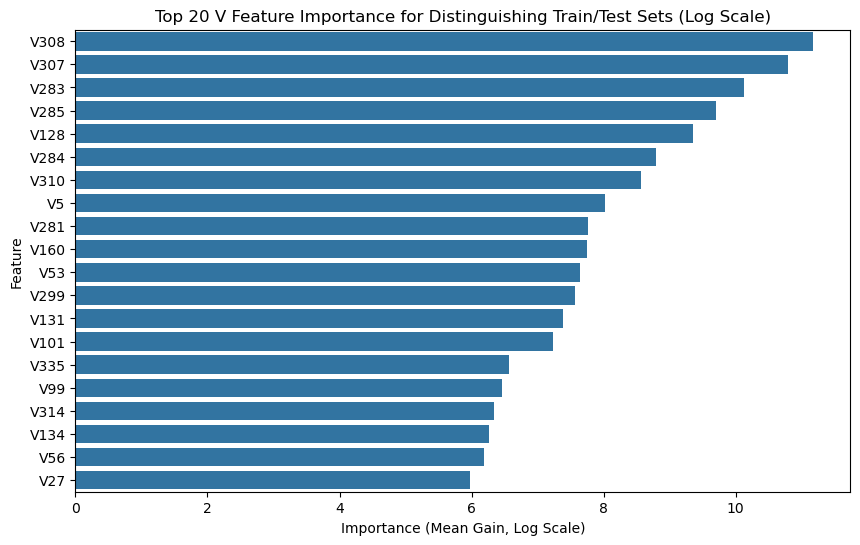

In [74]:
# Plot feature importance descending order
just_V = importance_table[importance_table["feature"].str.startswith("V")].sort_values("mean_gain", ascending=False).reset_index(drop=True)
top_amount = 20
plt.figure(figsize=(10, 6))
sns.barplot(x=np.log(just_V[: top_amount]["mean_gain"]), y=just_V[: top_amount]["feature"])
plt.title(f"Top {top_amount} V Feature Importance for Distinguishing Train/Test Sets (Log Scale)")
plt.xlabel("Importance (Mean Gain, Log Scale)")
plt.ylabel("Feature")

Text(0, 0.5, 'Feature')

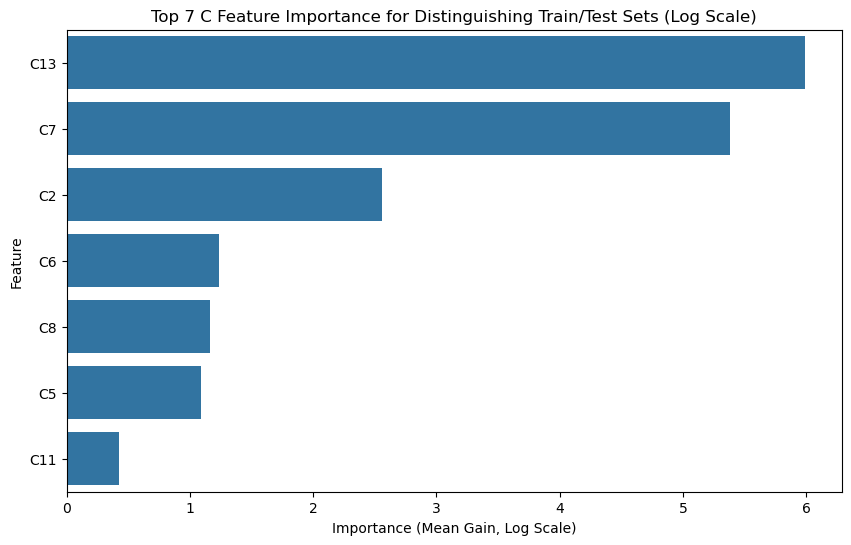

In [75]:
# Plot feature importance descending order
just_C = importance_table[importance_table["feature"].str.startswith("C")].sort_values("mean_gain", ascending=False).reset_index(drop=True)
top_amount = 7
plt.figure(figsize=(10, 6))
sns.barplot(x=np.log(just_C[: top_amount]["mean_gain"]), y=just_C[: top_amount]["feature"])
plt.title(f"Top {top_amount} C Feature Importance for Distinguishing Train/Test Sets (Log Scale)")
plt.xlabel("Importance (Mean Gain, Log Scale)")
plt.ylabel("Feature")

In [64]:
# Percentage of non-missing values
float((df_adv.shape[0] - df_adv["dist1"].isna().sum()) / df_adv.shape[0] * 100)

40.3476479154672

In [77]:
len(df_adv["uid"].value_counts()), df_adv.shape[0]

(217850, 590540)

In [ ]:
# X_train['day'] = X_train.TransactionDT / (24*60*60)
# X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)